In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
# Define file paths
train_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\train.csv"
test_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\test.csv"
dev_path = r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project\data\Processed_data\FR\dev.csv"

# Load the datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
dev_df = pd.read_csv(dev_path)

# train_df = train_df.reset_index()[["Time", "EUR/MWh"]]
# test_df = test_df.reset_index()[["Time", "EUR/MWh"]]
# dev_df = dev_df.reset_index()[["Time", "EUR/MWh"]]

# Get number of rows in each dataset
n_train = len(train_df)
n_test = len(test_df)
n_dev = len(dev_df)
n_total = n_train + n_test + n_dev

# Display shapes and percentages
print(f"Train set shape: {train_df.shape} → {100 * n_train / n_total:.2f}% of total data")
print(f"Test set shape:  {test_df.shape} → {100 * n_test / n_total:.2f}% of total data")
print(f"Dev set shape:   {dev_df.shape} → {100 * n_dev / n_total:.2f}% of total data")


# Optionally preview the first few rows
train_df.head()


Train set shape: (35060, 8) → 66.65% of total data
Test set shape:  (8759, 8) → 16.65% of total data
Dev set shape:   (8783, 8) → 16.70% of total data


,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,date
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,2019-10-01
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,2019-10-01
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,2019-10-01
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,2019-10-01
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,2019-10-01


In [6]:
print(1)

1


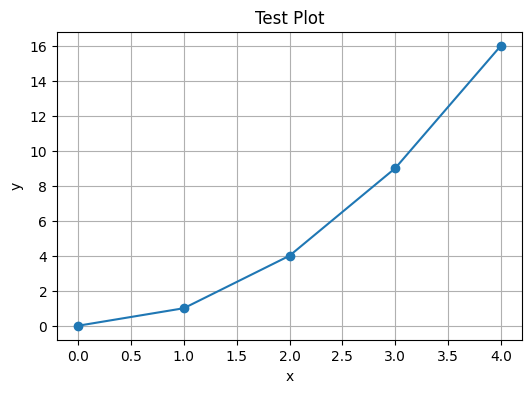

In [9]:
x = [0, 1, 2, 3, 4]
y = [0, 1, 4, 9, 16]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y, marker='o')
plt.title("Test Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

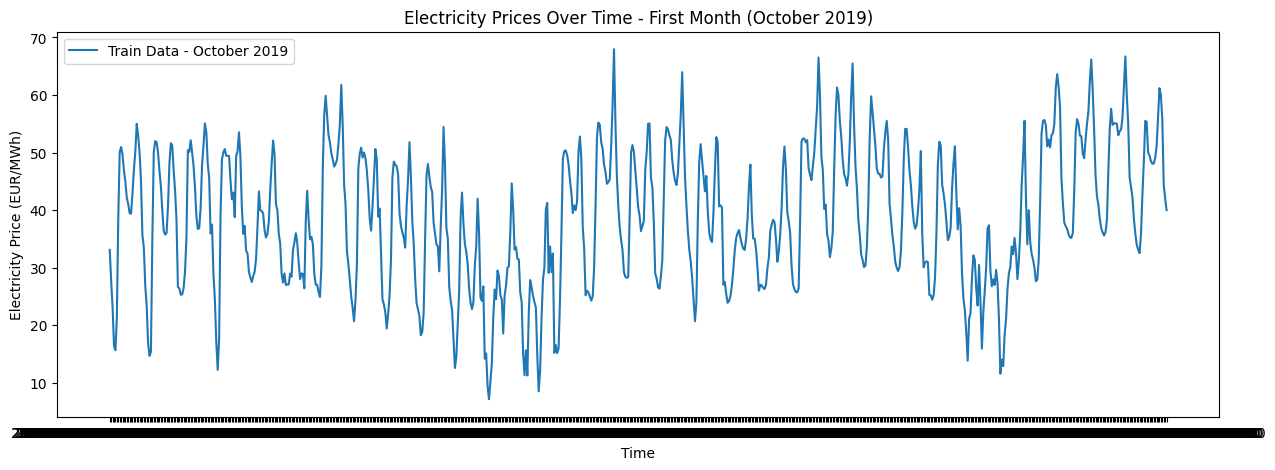

In [11]:
# Filter the first month (October 2019)
first_month = train_df[(train_df["Time"] >= "2019-10-01") & (train_df["Time"] < "2019-11-01")]

# Plot the first month
plt.figure(figsize=(15, 5))
plt.plot(first_month["Time"], first_month["EUR/MWh"], label="Train Data - October 2019", linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - First Month (October 2019)")
plt.legend()
plt.grid(False)
plt.show()

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

In [16]:
# Prepare train data
train_series = train_df["EUR/MWh"].values.reshape(-1,1)
dev_series = dev_df["EUR/MWh"].values.reshape(-1,1)
test_series = test_df["EUR/MWh"].values.reshape(-1,1)
# Scale data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series)
dev_scaled = scaler.transform(dev_series)
test_scaled= scaler.transform(test_series)

# Create sliding windows for train
window_size = 24*7
X_train, y_train = [], []
for i in range(len(train_scaled) - window_size):
    X_train.append(train_scaled[i:i+window_size].flatten())
    y_train.append(train_scaled[i+window_size])
X_train, y_train = np.array(X_train), np.array(y_train)

# Create sliding windows for dev
X_dev, y_dev = [], []
for i in range(len(dev_scaled) - window_size):
    X_dev.append(dev_scaled[i:i+window_size].flatten())
    y_dev.append(dev_scaled[i+window_size])
X_dev, y_dev = np.array(X_dev), np.array(y_dev)

# Test
# Create sliding windows for dev
X_test, y_test = [], []
for i in range(len(test_scaled) - window_size):
    X_test.append(test_scaled[i:i+window_size].flatten())
    y_test.append(test_scaled[i+window_size])
X_test, y_test = np.array(X_test), np.array(y_test)

In [58]:
model = Sequential([Dense(1, input_shape=(window_size,), activation='linear')])
model.compile(optimizer='adam', loss='mse')

# Train model with explicit validation data
history_1 = model.fit(X_train, y_train, 
                    epochs=10, batch_size=64,
                    validation_data=(X_dev, y_dev))

Epoch 1/10


c:\Users\pierr\anaconda3\envs\CS230\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.5113e-04 - val_loss: 1.0583e-04
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4206e-04 - val_loss: 5.5856e-05
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7283e-04 - val_loss: 3.9574e-05
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4645e-04 - val_loss: 3.9697e-05
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.2743e-04 - val_loss: 2.6452e-05
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.1176e-04 - val_loss: 2.2592e-05
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.0395e-04 - val_loss: 2.1260e-05
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.4982e-05 - val_loss: 4.7379e-05
Epoch 9/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 9.3026e-05 - val_loss: 2.0964e-05
Epoch 10/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 8.5027e-05 - val_loss: 1.6869e-05


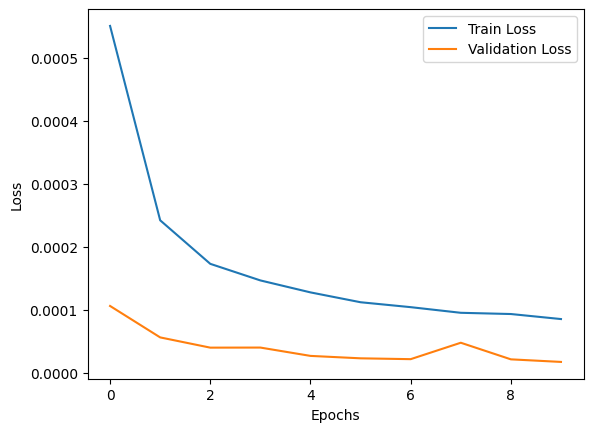

In [65]:
#plot la loss
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Weights (w): [ 9.67569128e-02 -2.18372568e-02 -2.01060306e-02  8.18413943e-02
 -2.68852990e-02 -9.73210707e-02  1.26033172e-01 -1.40687197e-01
  1.08593181e-01 -1.80368703e-02 -3.34225856e-02  2.39067357e-02
 -3.20328446e-03  1.02560938e-04 -9.66472477e-02  1.14798889e-01
 -6.55814167e-03 -7.89246932e-02 -6.97509423e-02  9.91494134e-02
 -5.62843792e-02  4.98094112e-02 -8.34976733e-02 -1.53708300e-02
  1.28219083e-01 -9.38712656e-02  1.35883272e-01 -6.63292632e-02
 -1.26551408e-02 -5.90482028e-03 -2.17368617e-03  6.24450259e-02
  6.21731617e-02 -7.87315741e-02 -3.25315744e-02  7.15635866e-02
  1.39801460e-03  4.59790081e-02 -7.65608922e-02  2.95109171e-02
 -7.50819594e-02  2.29800735e-02  5.07278033e-02  3.93197350e-02
 -1.52927428e-01  2.32613459e-02  5.09781465e-02 -1.90037861e-02
  7.05920160e-02 -6.57246076e-03 -3.73262800e-02  2.14212835e-02
  3.95822190e-02 -7.03269020e-02 -2.06494965e-02 -4.10893653e-03
  2.56786514e-02  2.44127009e-02 -6.25493377e-02 -4.30983305e-03
  6.93439618

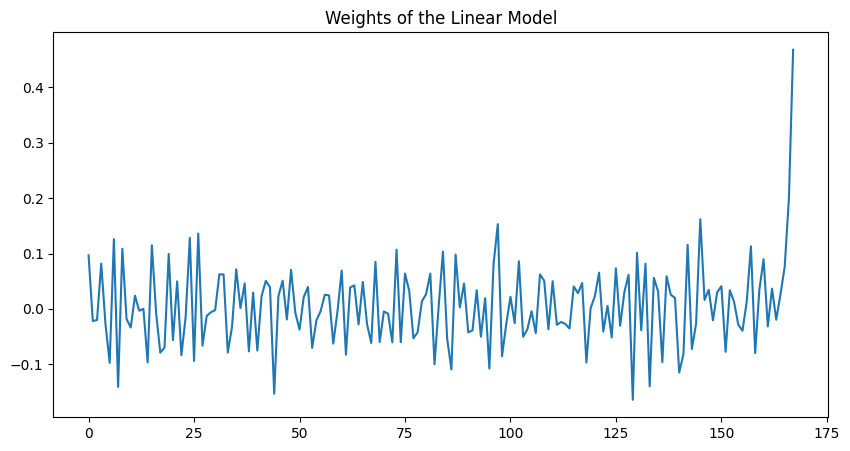

In [66]:
weights, bias = model.layers[0].get_weights()

print("Weights (w):", weights.flatten())   # flatten pour avoir un tableau 1D
print("Bias (b):", bias)
print("Number of weights:", len(weights.flatten()))

#plot the weights
plt.figure(figsize=(10, 5))
plt.plot(weights.flatten())
plt.title("Weights of the Linear Model")
plt.show()

In [61]:

def rMAE(y_true, y_pred):
    """
    Compute relative Mean Absolute Error (rMAE)
    comparing model prediction with naive baseline:
    y_hat_naive(t) = y_true(t - 24h)
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    
    shift = 24*7

    y_true_adj = y_true[shift:]
    y_pred_adj = y_pred[shift:]
    y_naive = y_true[:-shift]  # yesterday's value

    # Compute errors
    mae_model = np.mean(np.abs(y_true_adj - y_pred_adj))
    mae_naive = np.mean(np.abs(y_true_adj - y_naive))
    
    return mae_model / mae_naive


In [62]:
# Predict on dev set
y_pred_train_1 = model.predict(X_train)
y_pred_dev_1 = model.predict(X_dev)
y_pred_test_1 = model.predict(X_test)

# Compute rMAE
score_train_1= rMAE(y_train, y_pred_train_1)
score_dev_1 = rMAE(y_dev, y_pred_dev_1)
score_test_1 = rMAE(y_test, y_pred_test_1)
print(f"Relative MAE Train(rMAE): {score_train_1:.3f}")
print(f"Relative MAE Dev (rMAE): {score_dev_1:.3f}")
print(f"Relative MAE Test(rMAE): {score_test_1:.3f}")


1091/1091 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Relative MAE Train(rMAE): 0.335
Relative MAE Dev (rMAE): 0.343
Relative MAE Test(rMAE): 0.349


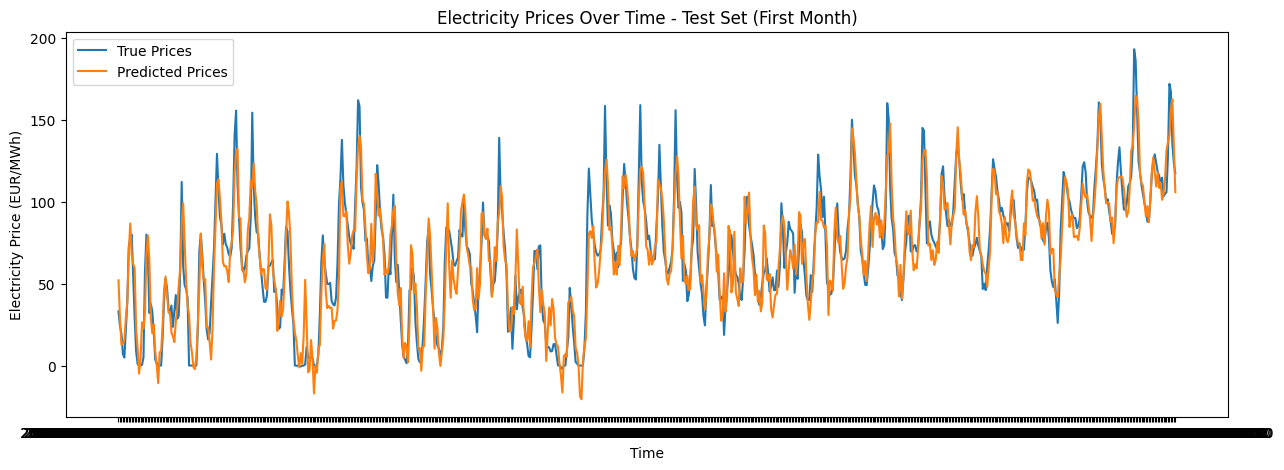

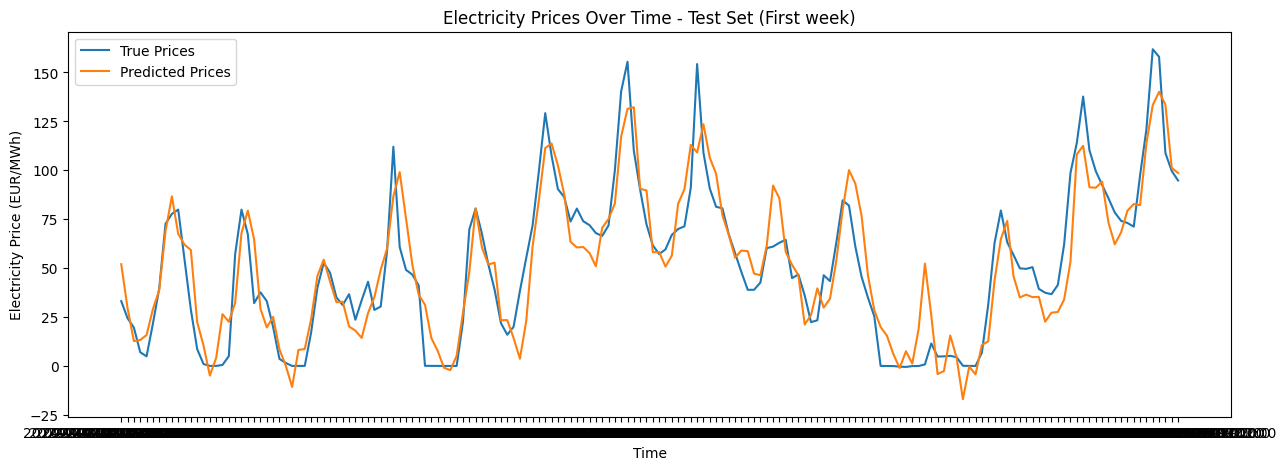

In [67]:


# Ensure y_test and y_pred_test are 2D
y_test = y_test.reshape(-1, 1)
y_pred_test = y_pred_test_1.reshape(-1, 1)

# Inverse transform predictions and true values
y_true_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_test)

# Plot one month (24h * 30)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_true_inv[:24*30],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_pred_inv[:24*30],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First Month)")
plt.legend()
plt.grid(False)
plt.show()

# Plot one month (24h * 7)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_true_inv[:24*7],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_pred_inv[:24*7],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First week)")
plt.legend()
plt.grid(False)
plt.show()

In [64]:


model2 = Sequential([
    Dense(64, input_shape=(window_size,), activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

model2.compile(optimizer='adam', loss='mse')

# Entraînement avec validation explicite
history_2 = model2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_dev, y_dev)
)


Epoch 1/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 1.7520e-04 - val_loss: 1.0325e-04
Epoch 2/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 9.3988e-05 - val_loss: 2.2101e-05
Epoch 3/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 9.0108e-05 - val_loss: 3.4697e-05
Epoch 4/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 8.0504e-05 - val_loss: 2.3321e-05
Epoch 5/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 7.8330e-05 - val_loss: 1.9504e-05
Epoch 6/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 7.5304e-05 - val_loss: 2.4776e-05
Epoch 7/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 7.5248e-05 - val_loss: 2.0485e-05
Epoch 8/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 7.4838e-05 - val_loss: 1.4234e-05
Epoch 9/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.6744e-05 - val_loss: 1.6028e-05
Epoch 10/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 6.9470e-05 - val_loss: 1.6694e-05
Epoch 11/20
1091/1091 ━━━━━━━━━━━━━━

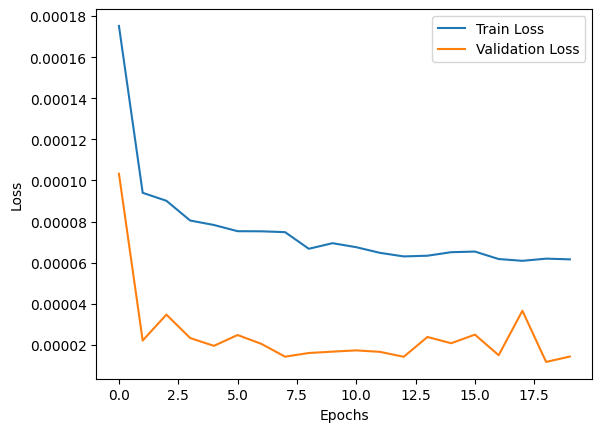

In [69]:
#plot la loss
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [70]:
# Predict on dev set
y_pred_train = model2.predict(X_train)
y_pred_dev = model2.predict(X_dev)
y_pred_test = model2.predict(X_test)

# Compute rMAE
score_train= rMAE(y_train, y_pred_train)
score_dev = rMAE(y_dev, y_pred_dev)
score_test = rMAE(y_test, y_pred_test)
print(f"Relative MAE Train(rMAE): {score_train:.3f}")
print(f"Relative MAE Dev (rMAE): {score_dev:.3f}")
print(f"Relative MAE Test(rMAE): {score_test:.3f}")

1091/1091 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Relative MAE Train(rMAE): 0.305
Relative MAE Dev (rMAE): 0.313
Relative MAE Test(rMAE): 0.307


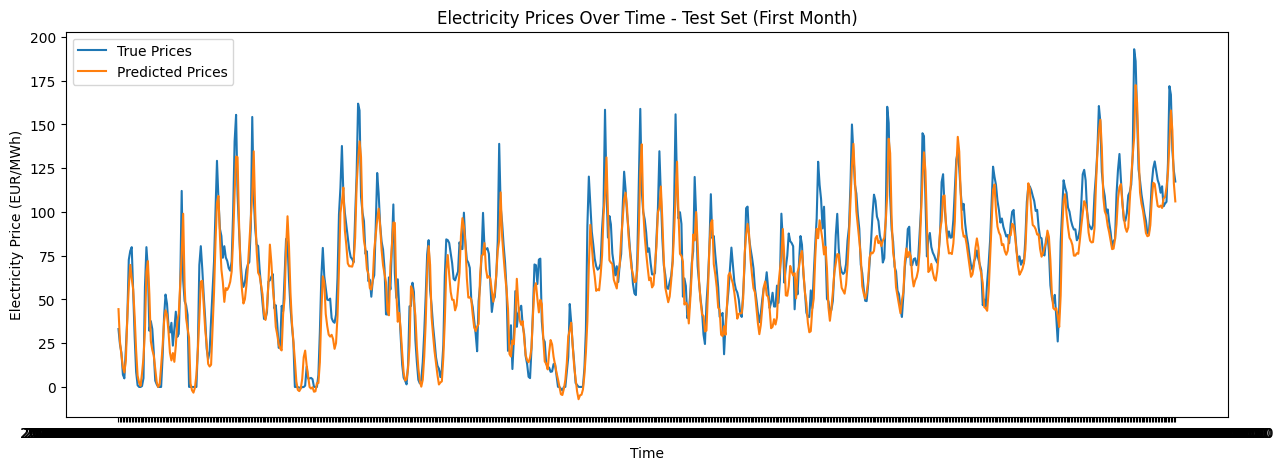

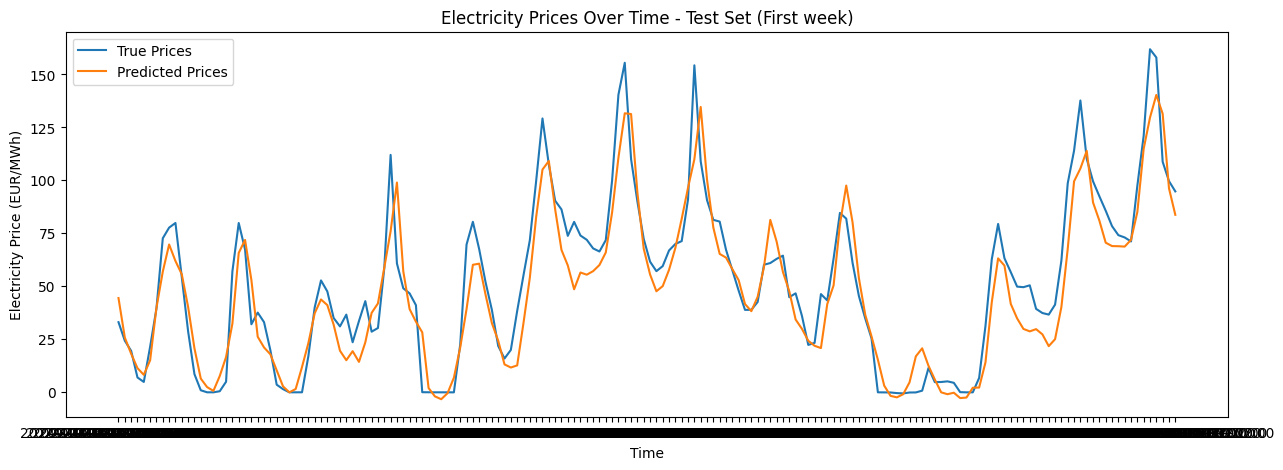

In [71]:
# Ensure y_test and y_pred_test are 2D
y_test = y_test.reshape(-1, 1)
y_pred_test = y_pred_test.reshape(-1, 1)

# Inverse transform predictions and true values
y_true_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_test)

# Plot one month (24h * 30)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_true_inv[:24*30],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_pred_inv[:24*30],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First Month)")
plt.legend()
plt.grid(False)
plt.show()

# Plot one month (24h * 7)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_true_inv[:24*7],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_pred_inv[:24*7],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First week)")
plt.legend()
plt.grid(False)
plt.show()

In [72]:
from tensorflow.keras.layers import Conv1D, Flatten

X_train = X_train.reshape(-1, window_size, 1)
X_dev   = X_dev.reshape(-1, window_size, 1)
X_test  = X_test.reshape(-1, window_size, 1)

model_conv = Sequential([
    Conv1D(32, kernel_size=24, activation='relu', input_shape=(window_size, 1)),
    Flatten(),  # <--- étape essentielle pour passer de 3D à 2D
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

model_conv.compile(optimizer='adam', loss='mse')

# Entraînement avec validation explicite
history_conv = model_conv.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_dev, y_dev)
)


Epoch 1/20


c:\Users\pierr\anaconda3\envs\CS230\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1091/1091 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 1.8173e-04 - val_loss: 7.1451e-05
Epoch 2/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 1.0080e-04 - val_loss: 3.6034e-05
Epoch 3/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - loss: 9.1722e-05 - val_loss: 3.8872e-05
Epoch 4/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 9.2449e-05 - val_loss: 1.8609e-05
Epoch 5/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 7.8030e-05 - val_loss: 2.4334e-05
Epoch 6/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 7.3736e-05 - val_loss: 3.1440e-05
Epoch 7/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 7.4323e-05 - val_loss: 1.5382e-05
Epoch 8/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - loss: 6.7448e-05 - val_loss: 2.4213e-05
Epoch 9/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 6.7902e-05 - val_loss: 1.5651e-05
Epoch 10/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 6.7475e-05 - val_loss: 2.0691e-05
Epoch 11/20
1091/1091 ━━━━━━━━

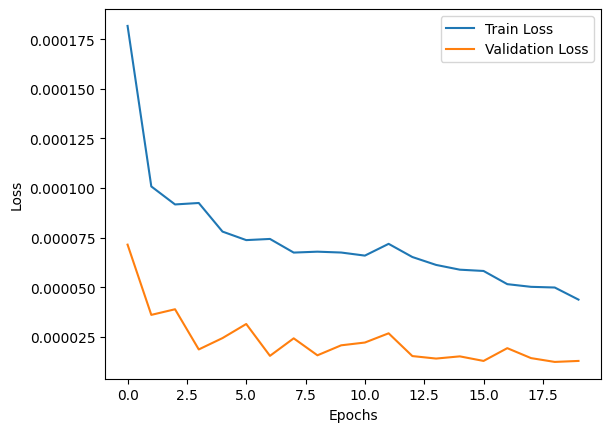

In [74]:
#plot la loss
plt.plot(history_conv.history['loss'], label='Train Loss')
plt.plot(history_conv.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [75]:
# Predict on dev set
y_pred_train = model_conv.predict(X_train)
y_pred_dev = model_conv.predict(X_dev)
y_pred_test = model_conv.predict(X_test)

# Compute rMAE
score_train= rMAE(y_train, y_pred_train)
score_dev = rMAE(y_dev, y_pred_dev)
score_test = rMAE(y_test, y_pred_test)
print(f"Relative MAE Train(rMAE): {score_train:.3f}")
print(f"Relative MAE Dev (rMAE): {score_dev:.3f}")
print(f"Relative MAE Test(rMAE): {score_test:.3f}")

1091/1091 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
Relative MAE Train(rMAE): 0.325
Relative MAE Dev (rMAE): 0.297
Relative MAE Test(rMAE): 0.295


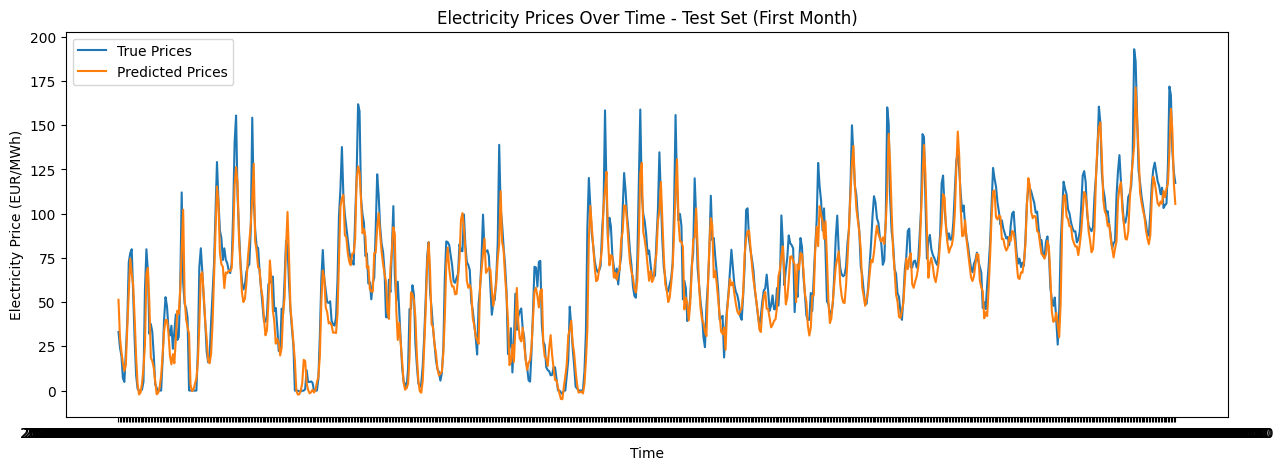

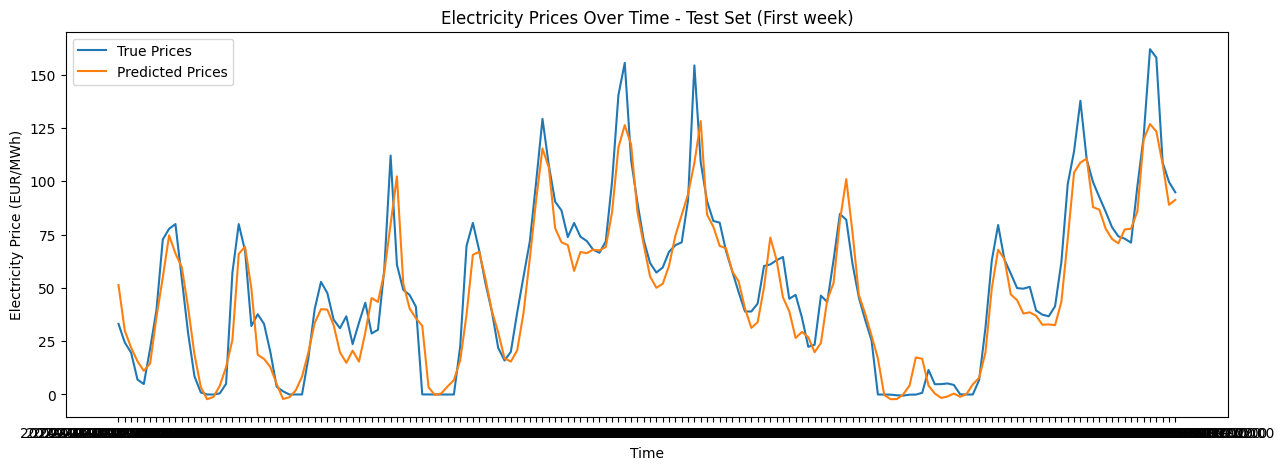

In [76]:
# Ensure y_test and y_pred_test are 2D
y_test = y_test.reshape(-1, 1)
y_pred_test = y_pred_test.reshape(-1, 1)

# Inverse transform predictions and true values
y_true_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_test)

# Plot one month (24h * 30)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_true_inv[:24*30],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_pred_inv[:24*30],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First Month)")
plt.legend()
plt.grid(False)
plt.show()

# Plot one month (24h * 7)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_true_inv[:24*7],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_pred_inv[:24*7],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First week)")
plt.legend()
plt.grid(False)
plt.show()

In [48]:
from tensorflow.keras.layers import Convolution1D, MaxPooling1D, Flatten, GlobalAveragePooling1D

X_train = X_train.reshape(-1, window_size, 1)
X_dev   = X_dev.reshape(-1, window_size, 1)
X_test  = X_test.reshape(-1, window_size, 1)

model_conv = Sequential([
    Convolution1D(32, 3, activation='relu', input_shape=(window_size, 1)),
    MaxPooling1D(2),
    Convolution1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Convolution1D(128, 3, activation='relu'),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

model_conv.compile(optimizer='adam', loss='mse')

# Entraînement avec validation explicite
history_conv = model_conv.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_dev, y_dev)
)


c:\Users\pierr\anaconda3\envs\CS230\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 49s 40ms/step - loss: 3.7031e-04 - val_loss: 1.2279e-04
Epoch 2/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - loss: 3.3166e-04 - val_loss: 1.2723e-04
Epoch 3/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - loss: 3.2528e-04 - val_loss: 1.3376e-04
Epoch 4/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step - loss: 3.2505e-04 - val_loss: 1.3583e-04
Epoch 5/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - loss: 3.1659e-04 - val_loss: 1.2717e-04
Epoch 6/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - loss: 3.1474e-04 - val_loss: 1.4121e-04
Epoch 7/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 53s 48ms/step - loss: 3.1084e-04 - val_loss: 1.1505e-04
Epoch 8/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 68s 62ms/step - loss: 3.0636e-04 - val_loss: 1.3971e-04
Epoch 9/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 96s 88ms/step - loss: 3.0350e-04 - val_loss: 1.3907e-04
Epoch 10/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 97s 89ms/step - loss: 2.9725e-04 - val_loss: 1.1494e-04
Epoch 11/20
1091/10

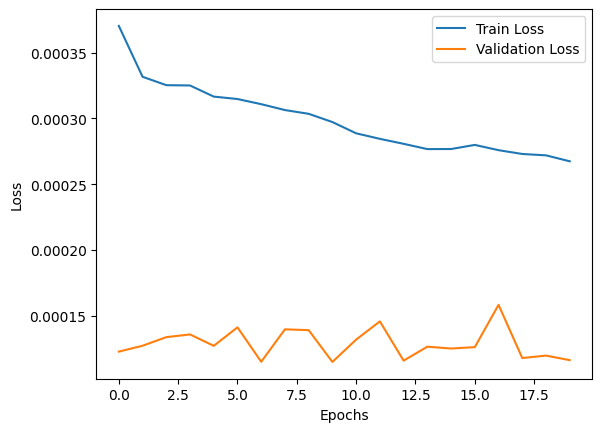

In [49]:
#plot la loss
plt.plot(history_conv.history['loss'], label='Train Loss')
plt.plot(history_conv.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [73]:
# Predict on dev set
y_pred_train = model_conv.predict(X_train)
y_pred_dev = model_conv.predict(X_dev)
y_pred_test = model_conv.predict(X_test)

# Compute rMAE
score_train= rMAE(y_train, y_pred_train)
score_dev = rMAE(y_dev, y_pred_dev)
score_test = rMAE(y_test, y_pred_test)
print(f"Relative MAE Train(rMAE): {score_train:.3f}")
print(f"Relative MAE Dev (rMAE): {score_dev:.3f}")
print(f"Relative MAE Test(rMAE): {score_test:.3f}")

1091/1091 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step
Relative MAE Train(rMAE): 0.325
Relative MAE Dev (rMAE): 0.297
Relative MAE Test(rMAE): 0.295


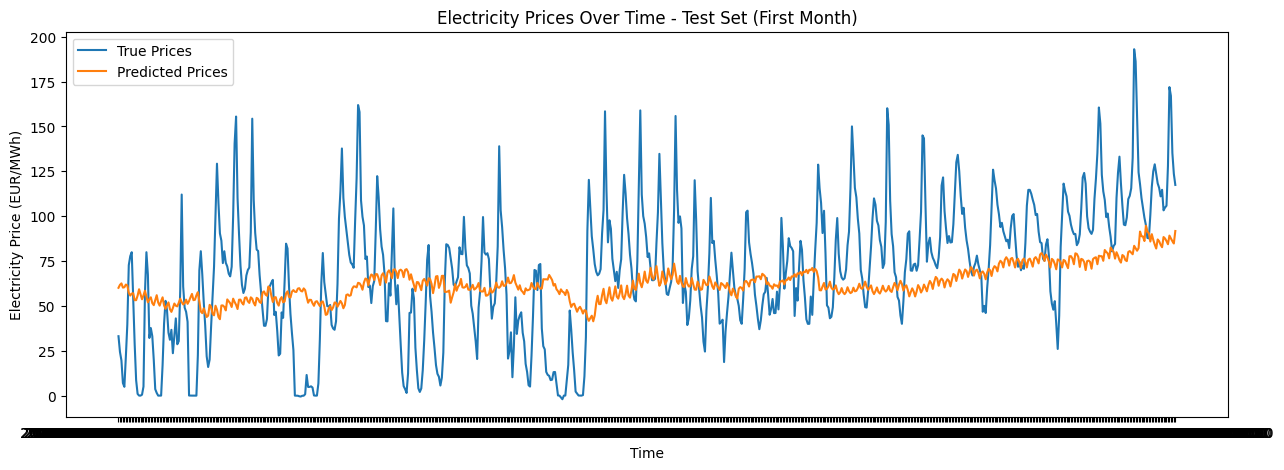

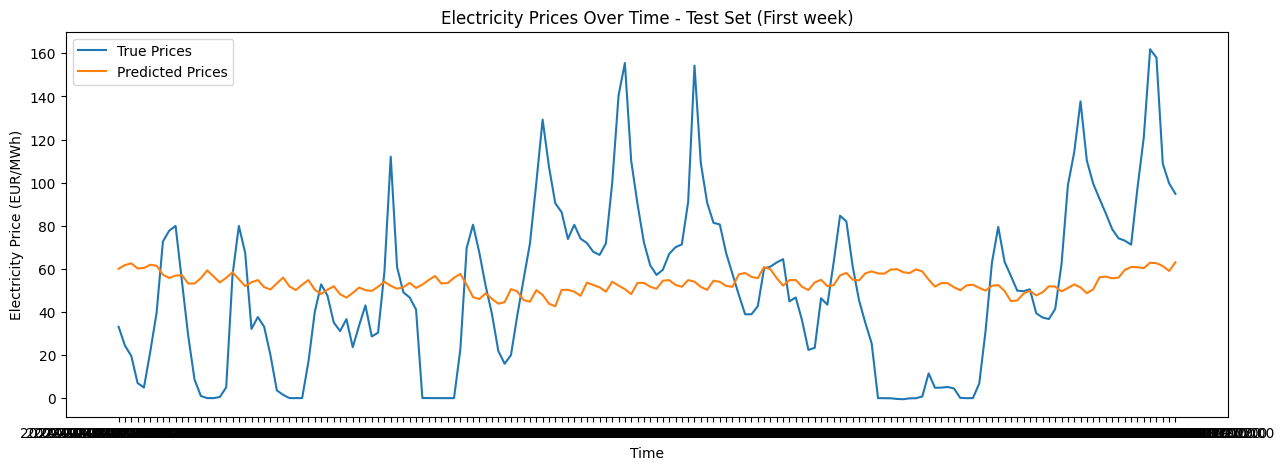

In [51]:
# Ensure y_test and y_pred_test are 2D
y_test = y_test.reshape(-1, 1)
y_pred_test = y_pred_test.reshape(-1, 1)

# Inverse transform predictions and true values
y_true_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_test)

# Plot one month (24h * 30)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_true_inv[:24*30],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*30],
    y_pred_inv[:24*30],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First Month)")
plt.legend()
plt.grid(False)
plt.show()

# Plot one month (24h * 7)
plt.figure(figsize=(15, 5))
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_true_inv[:24*7],
    label="True Prices", linewidth=1.5
)
plt.plot(
    test_df["Time"].iloc[window_size:window_size + 24*7],
    y_pred_inv[:24*7],
    label="Predicted Prices", linewidth=1.5
)
plt.xlabel("Time")
plt.ylabel("Electricity Price (EUR/MWh)")
plt.title("Electricity Prices Over Time - Test Set (First week)")
plt.legend()
plt.grid(False)
plt.show()